In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')

print(X.head())
print(X.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000

In [3]:
# Importowanie bibliotek
from sklearn.datasets import load_iris
import pandas as pd
# Wczytaj zbiór danych
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name='target')
# Wyświetl pierwsze 5 rekordów
print(X.head())
# Podstawowe statystyki
print(X.describe())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000

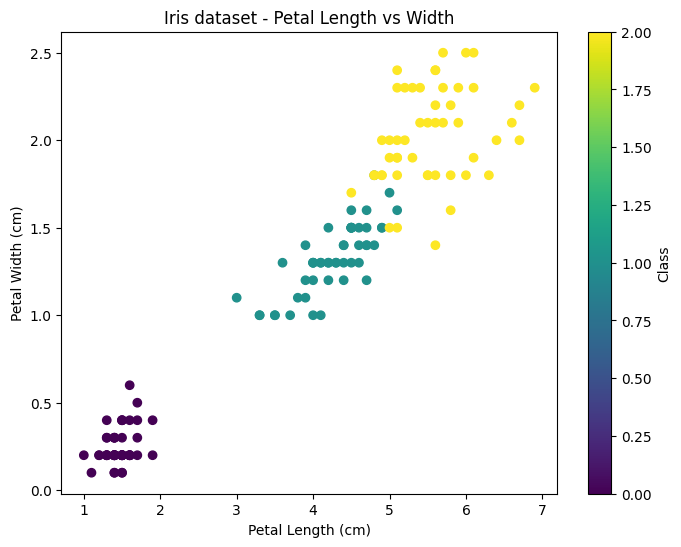

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [4]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c=y,
cmap='viridis')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris dataset - Petal Length vs Width')
plt.colorbar(label='Class')
plt.show()

# Podstawowe statystyki
print(X.describe())

In [5]:
from sklearn.model_selection import train_test_split

# Podział danych
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
random_state=42)

print(f"Rozmiar zbioru treningowego: {X_train.shape}")
print(f"Rozmiar zbioru testowego: {X_test.shape}")

Rozmiar zbioru treningowego: (105, 4)
Rozmiar zbioru testowego: (45, 4)


In [6]:
from sklearn.neural_network import MLPClassifier

# Model MLP
mlp = MLPClassifier(hidden_layer_sizes=(10,), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

# Ocena modelu
train_accuracy = mlp.score(X_train, y_train)
test_accuracy = mlp.score(X_test, y_test)

print(f"Dokładność na zbiorze treningowym: {train_accuracy:.2f}")
print(f"Dokładność na zbiorze testowym: {test_accuracy:.2f}")

Dokładność na zbiorze treningowym: 0.98
Dokładność na zbiorze testowym: 0.98


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


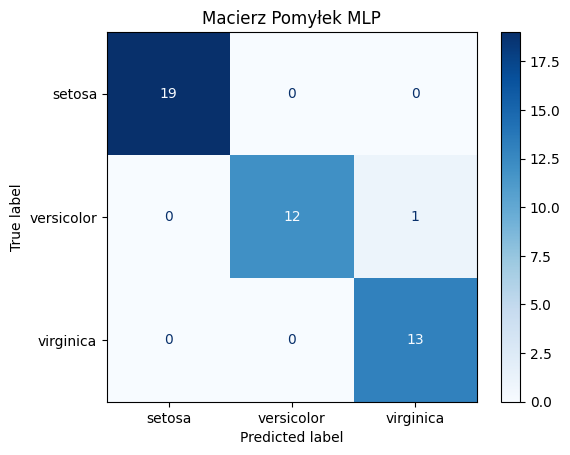

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Macierz pomyłek
y_pred = mlp.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Macierz Pomyłek MLP')
plt.show()

In [10]:
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Siatka hiperparametrów
param_grid = {
    'hidden_layer_sizes': [(5,), (10,), (20,), (10,10)],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate': ['constant', 'adaptive']
}

grid_search = GridSearchCV(MLPClassifier(max_iter=5000, random_state=42), param_grid,
cv=5)
grid_search.fit(X_train, y_train)

print(f"Najlepsze parametry: {grid_search.best_params_}")
print(f"Dokładność na zbiorze testowym: {grid_search.score(X_test, y_test):.2f}")

Najlepsze parametry: {'alpha': 0.0001, 'hidden_layer_sizes': (5,), 'learning_rate': 'constant'}
Dokładność na zbiorze testowym: 0.98


In [11]:
import numpy as np

# Predykcja dla nowego przykładu
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])
predicted_class = grid_search.best_estimator_.predict(new_sample)
print(f"Nowy przykład został zaklasyfikowany jako: {iris.target_names[predicted_class][0]}")

Nowy przykład został zaklasyfikowany jako: setosa
